In [2]:
# ---------------------------------
# PINN: Von Karman Vortex (Re=100)
# ---------------------------------
import scipy.io
import numpy as np
import tensorflow as tf
import sys
import os
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

sys.path.append(os.path.abspath(os.path.join(current_dir, '..')))
from model import PhysicsInformedNN

In [7]:
# -------------------------------
# Main 1: Train Von Kármán Vortex
# -------------------------------

if __name__ == "__main__": 
    
    # Hyperparameters configuration
    N_train = 5000
    layers = [3, 50, 50, 50, 50, 50, 50, 50, 50, 2]
    
    # Load simulation data
    data = scipy.io.loadmat('../Data/cylinder_nektar_wake.mat')
    U_star = data['U_star'] 
    P_star = data['p_star'] 
    t_star = data['t']      
    X_star = data['X_star'] 

    x_star = X_star[:,0:1]; y_star = X_star[:,1:2]
    N = X_star.shape[0]; T = t_star.shape[0]

    # Grid tile and data flattening
    XX = np.tile(X_star[:,0:1], (1,T)); YY = np.tile(X_star[:,1:2], (1,T)); TT = np.tile(t_star, (1,N)).T 
    UU = U_star[:,0,:]; VV = U_star[:,1,:]; PP = P_star 
    
    x = XX.flatten()[:,None]; y = YY.flatten()[:,None]; t = TT.flatten()[:,None] 
    u = UU.flatten()[:,None]; v = VV.flatten()[:,None]; p = PP.flatten()[:,None] 

    # Domain bounds
    lb = np.array([x.min(), y.min(), t.min()])
    ub = np.array([x.max(), y.max(), t.max()])
    lb_tf = tf.constant(lb, dtype=tf.float32)
    ub_tf = tf.constant(ub, dtype=tf.float32)

    # Random selection of training points
    idx = np.random.choice(N*T, N_train, replace=False)
    x_train = x[idx,:]; y_train = y[idx,:]; t_train = t[idx,:]
    u_train = u[idx,:]; v_train = v[idx,:]

    # Convert to TensorFlow tensors
    x_tf = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)
    t_tf = tf.convert_to_tensor(t_train, dtype=tf.float32)
    u_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)
    v_tf = tf.convert_to_tensor(v_train, dtype=tf.float32)

    # Training
    model = PhysicsInformedNN(layers, lb_tf, ub_tf)
    
    print("   >>> Phase 1: Data Fitting ...")
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, epochs=3000, train_params=False, physics_weight=0.0)

    model.reset_optimizer()

    print("   >>> Phase 2: Physics Discovery ...")
    model.train(x_tf, y_tf, t_tf, u_tf, v_tf, epochs=25000, train_params=True, physics_weight=1.0)
    
    # Prediction and Exportation
    snap = 90 
    if snap >= T: snap = T-1

    x_star_test = X_star[:,0:1]
    y_star_test = X_star[:,1:2]
    t_star_test = TT[:, snap] 
    
    x_test_tf = tf.reshape(tf.convert_to_tensor(x_star_test, dtype=tf.float32), [-1, 1])
    y_test_tf = tf.reshape(tf.convert_to_tensor(y_star_test, dtype=tf.float32), [-1, 1])
    t_test_tf = tf.reshape(tf.convert_to_tensor(t_star_test, dtype=tf.float32), [-1, 1])

    # Model prediction
    u_pred_tf, v_pred_tf, p_pred_tf, _, _ = model.net_NS(x_test_tf, y_test_tf, t_test_tf)
    
    # Retrieve identified parameters
    lambda_1_value = model.lambda_1.numpy()[0]
    lambda_2_value = model.lambda_2.numpy()[0]

    # Retrieve loss history
    loss_total = np.array(model.loss_history['total'])
    loss_data = np.array(model.loss_history['data'])
    loss_phys = np.array(model.loss_history['phys'])

    # Save results to compressed .npz file
    np.savez('Results/Karman/cylinder_results.npz',
             u_pred=u_pred_tf.numpy(), 
             v_pred=v_pred_tf.numpy(), 
             p_pred=p_pred_tf.numpy(), 
             lambda_1=model.lambda_1.numpy()[0], 
             lambda_2=model.lambda_2.numpy()[0],
             x_train=x_train, y_train=y_train, snap=snap,
             loss_total=loss_total, 
             loss_data=loss_data, 
             loss_phys=loss_phys)
             
    print('Done!')

   >>> Phase 1: Data Fitting ...
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('physics_weight', 'self', 'train_params'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('physics_weight', 'self', 'train_params'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


/home/forero/Dev/venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:735: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


It: 0 [PARAMS:OFF|PHYS:OFF], Loss: 8.984e-01, l1: 1.0000, l2: 0.01000, Time: 5.99s
It: 100 [PARAMS:OFF|PHYS:OFF], Loss: 1.656e-01, l1: 1.0000, l2: 0.01000, Time: 66.24s
It: 200 [PARAMS:OFF|PHYS:OFF], Loss: 1.108e-01, l1: 1.0000, l2: 0.01000, Time: 68.23s
It: 300 [PARAMS:OFF|PHYS:OFF], Loss: 9.405e-02, l1: 1.0000, l2: 0.01000, Time: 69.85s
It: 400 [PARAMS:OFF|PHYS:OFF], Loss: 9.307e-02, l1: 1.0000, l2: 0.01000, Time: 69.53s
It: 500 [PARAMS:OFF|PHYS:OFF], Loss: 9.304e-02, l1: 1.0000, l2: 0.01000, Time: 70.06s
It: 600 [PARAMS:OFF|PHYS:OFF], Loss: 9.198e-02, l1: 1.0000, l2: 0.01000, Time: 70.65s
It: 700 [PARAMS:OFF|PHYS:OFF], Loss: 9.167e-02, l1: 1.0000, l2: 0.01000, Time: 69.68s
It: 800 [PARAMS:OFF|PHYS:OFF], Loss: 9.060e-02, l1: 1.0000, l2: 0.01000, Time: 66.74s
It: 900 [PARAMS:OFF|PHYS:OFF], Loss: 8.958e-02, l1: 1.0000, l2: 0.01000, Time: 62.47s
It: 1000 [PARAMS:OFF|PHYS:OFF], Loss: 8.945e-02, l1: 1.0000, l2: 0.01000, Time: 62.54s
It: 1100 [PARAMS:OFF|PHYS:OFF], Loss: 8.838e-02, l1: 1.0

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MaxNLocator  
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as ticker
import os

In [2]:
# Visual setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

def plot_3d_surface(X, Y, Z, z_label, x_train, y_train, fig_size=(9, 8), plot_title=None, vmin=None, vmax=None, norm=None, ticks=None):
    """Función modular para graficar superficies 3D con normalización específica."""
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.9, edgecolor='none', 
                           vmin=vmin, vmax=vmax, norm=norm)

    if plot_title:
        ax.set_title(plot_title, fontsize=20, pad=15)
    
    # Axis configuration
    z_min = np.min(Z) - 0.2
    ax.set_zlim(z_min, np.max(Z))
    ax.scatter(x_train, y_train, np.full_like(x_train, z_min), c='k', marker='.', s=1, alpha=0.2)
    
    # Z-axis tick reduction to prevent saturation
    ax.zaxis.set_major_locator(MaxNLocator(nbins=4)) 
    
    ax.view_init(elev=35, azim=45)
    ax.set_xlabel('$x$', fontsize=18, labelpad=10)
    ax.set_ylabel('$y$', fontsize=18, labelpad=10)
    ax.set_zlabel(z_label, fontsize=18, rotation=0, labelpad=20)
    ax.set_box_aspect((2.5, 1.5, 0.5))
    
    # Color bar
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1, ticks=ticks)
    label_text = z_label.replace('$','').split('(')[0] 
    cbar.set_label(f'${label_text}$', rotation=0, labelpad=15, fontsize=16)
    
    return fig

--- SNAPSHOT INFO ---
Snapshot index: 90
Physical time (t): 9.0000

--- PERFORMANCE METRICS ---
Relative L2 (U): 9.1638e-03
Relative L2 (V): 1.7436e-02
Relative L2 (P): 4.8189e-02

--- PRESSURE RANGES ---
Predicted Pressure (PINN) | Min: 0.1515, Max: 0.7542, Range: 0.6026
Exact Pressure            | Min: -0.5172, Max: 0.0719, Range: 0.5891


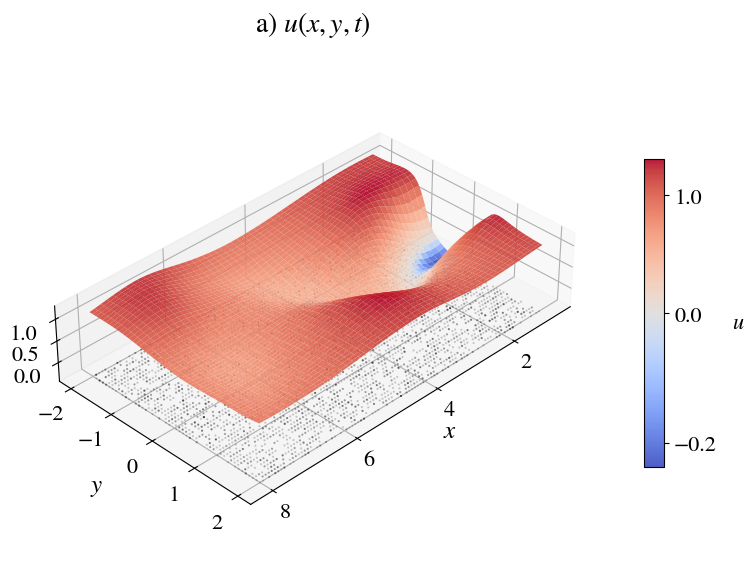

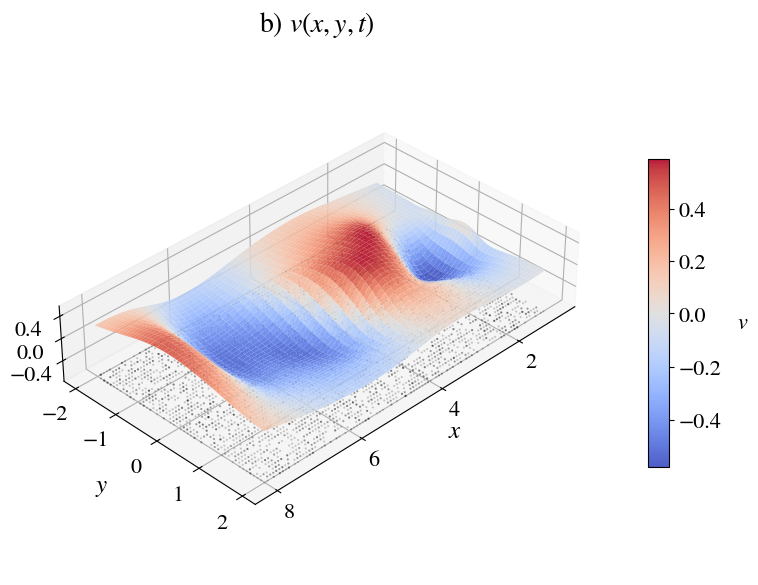

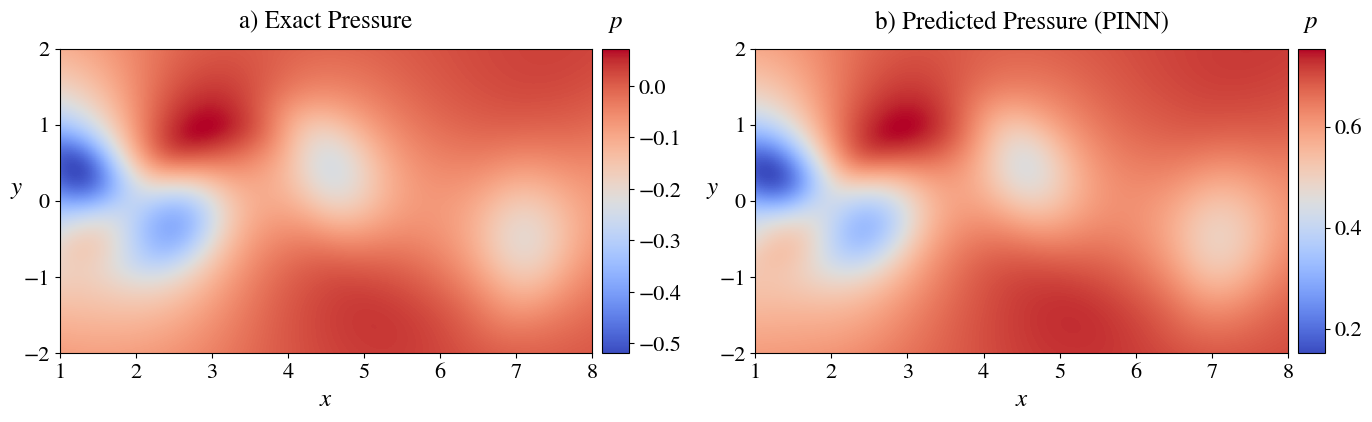

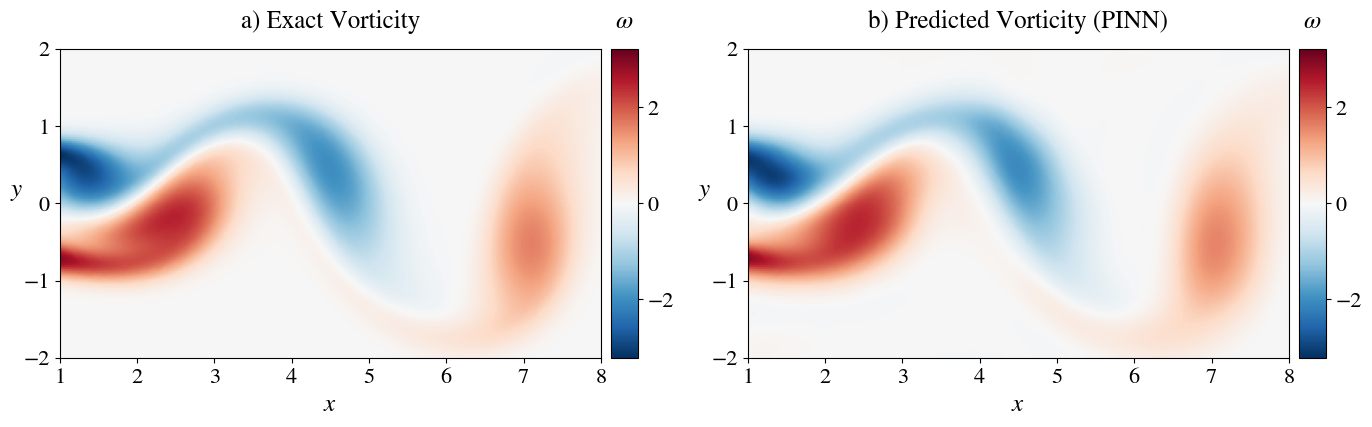

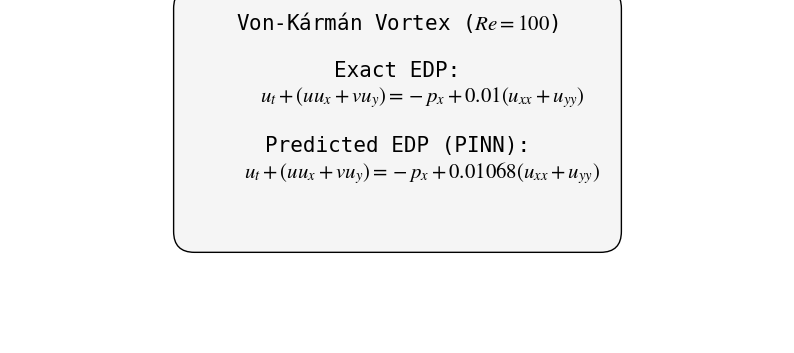

In [5]:
if __name__ == "__main__": 
    
    # Routes
    DATA_PATH = '../Data/cylinder_nektar_wake.mat'
    RESULTS_PATH = 'Results/Karman/cylinder_results.npz'
    SAVE_DIR = 'Results/Karman'
    os.makedirs(SAVE_DIR, exist_ok=True)
    
    # Load data
    data = scipy.io.loadmat(DATA_PATH)
    results = np.load(RESULTS_PATH)
    
    X_star = data['X_star']
    U_star = data['U_star'] 
    P_star = data['p_star']
    t_star = data['t'].flatten() 

    snap = int(results['snap'])
    current_time = t_star[snap]

    print(f"--- SNAPSHOT INFO ---")
    print(f"Snapshot index: {snap}")
    print(f"Physical time (t): {current_time:.4f}")
    
    u_pred = results['u_pred']
    v_pred = results['v_pred']
    p_pred = results['p_pred']
    snap = int(results['snap'])

    x_train = results['x_train']
    y_train = results['y_train']
    
    # Prepare Mesh
    lb = np.array([X_star[:,0].min(), X_star[:,1].min()])
    ub = np.array([X_star[:,0].max(), X_star[:,1].max()])
    nn_x, nn_y = 400, 150
    x_plot = np.linspace(lb[0], ub[0], nn_x)
    y_plot = np.linspace(lb[1], ub[1], nn_y)
    X, Y = np.meshgrid(x_plot, y_plot)

    # Metrics
    p_exact = P_star[:, snap]
    u_exact = U_star[:, 0, snap]
    v_exact = U_star[:, 1, snap]

    error_u = np.linalg.norm(u_exact.flatten() - u_pred.flatten(), 2) / np.linalg.norm(u_exact.flatten(), 2)
    error_v = np.linalg.norm(v_exact.flatten() - v_pred.flatten(), 2) / np.linalg.norm(v_exact.flatten(), 2)

    # Pressure centering for relative error calculation
    p_pred_centered = p_pred.flatten() - np.mean(p_pred.flatten())
    p_exact_centered = p_exact.flatten() - np.mean(p_exact.flatten())

    error_p = np.linalg.norm(p_exact_centered - p_pred_centered, 2) / np.linalg.norm(p_exact_centered, 2)

    print(f"\n--- PERFORMANCE METRICS ---")
    print(f"Relative L2 (U): {error_u:.4e}")
    print(f"Relative L2 (V): {error_v:.4e}")
    print(f"Relative L2 (P): {error_p:.4e}")

    # Min and max values
    p_pred_min, p_pred_max = np.min(p_pred), np.max(p_pred)
    p_exact_min, p_exact_max = np.min(p_exact), np.max(p_exact)

    print(f"\n--- PRESSURE RANGES ---")    
    print(f"Predicted Pressure (PINN) | Min: {p_pred_min:.4f}, Max: {p_pred_max:.4f}, Range: {p_pred_max - p_pred_min:.4f}")
    print(f"Exact Pressure            | Min: {p_exact_min:.4f}, Max: {p_exact_max:.4f}, Range: {p_exact_max - p_exact_min:.4f}")
    
    # Interpolation
    UU_star = griddata(X_star, u_pred.flatten(), (X, Y), method='cubic')
    VV_star = griddata(X_star, v_pred.flatten(), (X, Y), method='cubic')
    PP_star = griddata(X_star, p_pred.flatten(), (X, Y), method='cubic')
    U_exact_grid = griddata(X_star, u_exact.flatten(), (X, Y), method='cubic')
    V_exact_grid = griddata(X_star, v_exact.flatten(), (X, Y), method='cubic')
    P_exact = griddata(X_star, P_star[:, snap].flatten(), (X, Y), method='cubic')

    # Derivatives (Vorticity)
    dU_dy, dU_dx = np.gradient(griddata(X_star, U_star[:, 0, snap].flatten(), (X, Y), method='cubic'), y_plot, x_plot)
    dV_dy, dV_dx = np.gradient(griddata(X_star, U_star[:, 1, snap].flatten(), (X, Y), method='cubic'), y_plot, x_plot)
    W_exact = dV_dx - dU_dy
    
    dV_dy_p, dV_dx_p = np.gradient(VV_star, y_plot, x_plot)
    dU_dy_p, dU_dx_p = np.gradient(UU_star, y_plot, x_plot)
    W_pred = dV_dx_p - dU_dy_p

    # Mask
    mask = (X**2 + Y**2) <= (0.5)**2
    for var in [UU_star, VV_star, PP_star, P_exact, W_pred, W_exact]:
        var[mask] = np.nan

    # Plotting velocities (3D)
    vmin_u = min(np.min(U_exact_grid), np.min(UU_star))
    vmax_u = max(np.max(U_exact_grid), np.max(UU_star))
    norm_u = TwoSlopeNorm(vcenter=0, vmin=vmin_u, vmax=vmax_u)
    manual_ticks=[-0.2,0,1]
    
    fig_u = plot_3d_surface(X, Y, UU_star, '$u(x,y)$', x_train, y_train, fig_size=(9, 8), 
                        plot_title="a) $u(x,y,t)$", 
                        vmin=vmin_u, vmax=vmax_u, norm=norm_u, 
                        ticks=manual_ticks)
    
    fig_u.savefig(f'{SAVE_DIR}/Karman_U.png', dpi=300, bbox_inches='tight')

    vmin_v = min(np.min(V_exact_grid), np.min(VV_star))
    vmax_v = max(np.max(V_exact_grid), np.max(VV_star))
    norm_v = TwoSlopeNorm(vcenter=0, vmin=vmin_v, vmax=vmax_v)
    
    fig_v = plot_3d_surface(X, Y, VV_star, '$v(x,y)$', x_train, y_train, 
                        plot_title="b) $v(x,y,t)$", 
                        vmin=vmin_v, vmax=vmax_v, norm=norm_v)
    fig_v.savefig(f'{SAVE_DIR}/Karman_V.png', dpi=300, bbox_inches='tight')

    # Pressure (2D Plots) 
    fig_p = plt.figure(figsize=(14, 6))
    for i, (data_p, title) in enumerate(zip([P_exact, PP_star], ['a) Exact Pressure', 'b) Predicted Pressure (PINN)'])):
        ax = fig_p.add_subplot(1, 2, i+1)
        h = ax.imshow(data_p, origin='lower', extent=[lb[0], ub[0], lb[1], ub[1]], cmap='coolwarm')
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlabel('$x$', fontsize=18); ax.set_ylabel('$y$', fontsize=18, rotation=0, labelpad=5)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig_p.colorbar(h, cax=cax)
        cbar.ax.set_title('$p$', fontsize=18, pad=15)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/Karman_P.png', dpi=300, bbox_inches='tight')

    # Vorticity (2D Plots)
    fig_w = plt.figure(figsize=(14, 6))
    vmax = np.nanmax(np.abs(W_exact))
    for i, (data_w, title) in enumerate(zip([W_exact, W_pred], ['a) Exact Vorticity', 'b) Predicted Vorticity (PINN)'])):
        ax = fig_w.add_subplot(1, 2, i+1)
        h = ax.imshow(data_w, origin='lower', extent=[lb[0], ub[0], lb[1], ub[1]], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(title, fontsize=18, pad=15)
        ax.set_xlabel('$x$', fontsize=18); ax.set_ylabel('$y$', fontsize=18, rotation=0, labelpad=5)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = fig_w.colorbar(h, cax=cax)
        cbar.ax.set_title(r'$\omega$', fontsize=18, pad=15)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/Karman_Vorticity.png', dpi=300, bbox_inches='tight')

    # Discovery Results
    fig_txt = plt.figure(figsize=(10, 3))
    ax_txt = fig_txt.add_subplot(1, 1, 1)
    ax_txt.axis('off')
    txt = "Von-Kármán Vortex ($Re=100$)\n\n"
    txt += "Exact EDP:\n"
    txt += "    $u_t + (u u_x + v u_y) = -p_x + 0.01(u_{xx} + u_{yy})$\n\n"
    txt += "Predicted EDP (PINN):\n"
    txt += f"    $u_t + (u u_x + v u_y) = -p_x + {results['lambda_2']:.5f}(u_{{xx}} + u_{{yy}})$\n\n"
    ax_txt.text(0.5, 0.5, txt, fontsize=15, family='monospace', ha='center', bbox=dict(facecolor='whitesmoke', boxstyle='round,pad=1'))
    plt.savefig(f'{SAVE_DIR}/Karman_Results.png', dpi=300, bbox_inches='tight')

    plt.show()